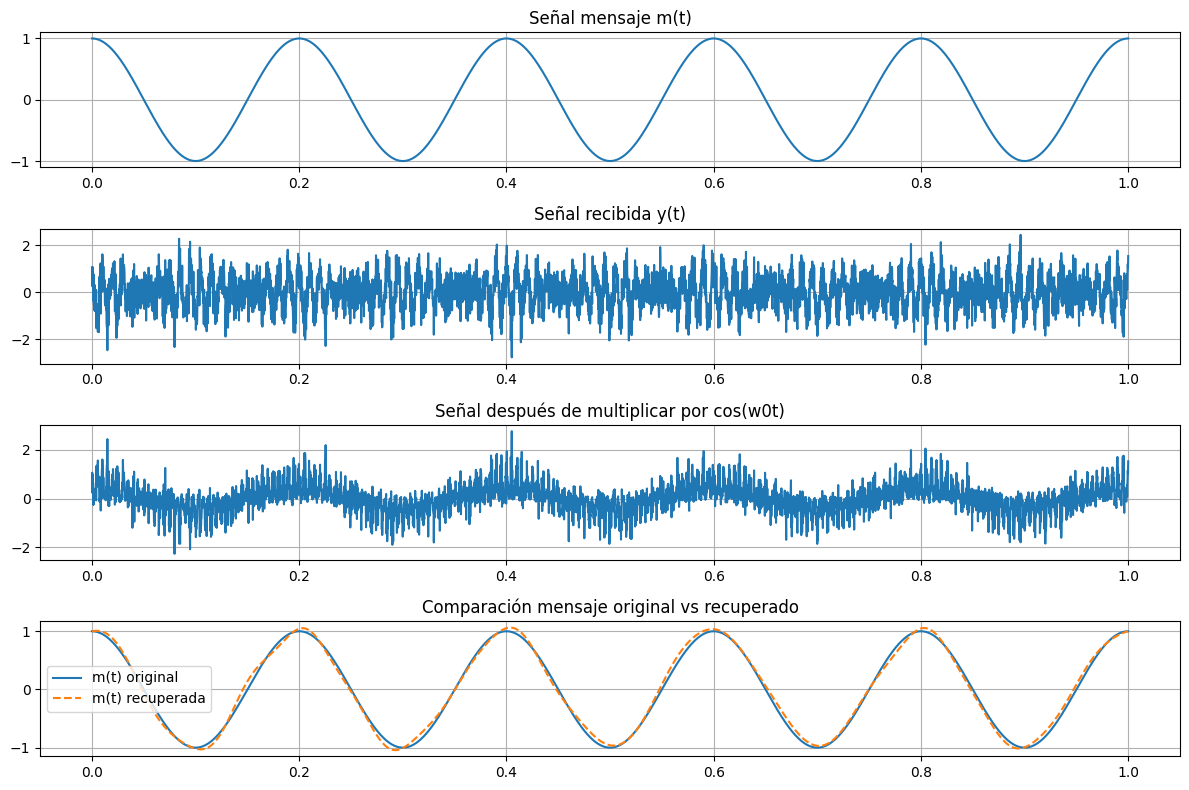

Potencia de la señal: 0.5001000165939331
Potencia del error/ruido: 0.003510227659717202
SNR: 142.46939086914062
SNR en dB: 21.537216186523438


In [1]:
import torch
import matplotlib.pyplot as plt

# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

fs = 5000                 # Frecuencia de muestreo [Hz]
Tsim = 1                  # Tiempo de simulación [s]
N = int(fs * Tsim)        # Número de muestras

t = torch.linspace(0, Tsim, N)

fm = 5                    # Frecuencia del mensaje [Hz]
fc = 100                  # Frecuencia portadora [Hz]

w0 = 2 * torch.pi * fc

sigma_n = 0.5             # Desviación estándar del ruido
phi = 0                   # Error de fase en demodulación

# ============================================================
# 2. SEÑAL MENSAJE m(t)
# ============================================================

m_t = torch.cos(2 * torch.pi * fm * t)

# ============================================================
# 3. RUIDO EN FASE Y CUADRATURA
# ============================================================

n_I = sigma_n * torch.randn(N)
n_Q = sigma_n * torch.randn(N)

# ============================================================
# 4. SEÑAL RECIBIDA EN BANDA PASANTE
# ============================================================

y_t = (
    m_t * torch.cos(w0 * t)
    + n_I * torch.cos(w0 * t)
    - n_Q * torch.sin(w0 * t)
)

# ============================================================
# 5. DEMODULACIÓN COHERENTE
# ============================================================

demod = y_t * torch.cos(w0 * t + phi)

# ============================================================
# 6. FILTRO PASA BAJAS SIMPLE EN FRECUENCIA
# ============================================================

Y = torch.fft.fft(demod)
freqs = torch.fft.fftfreq(N, d=1/fs)

cutoff = 20   # Frecuencia de corte del filtro pasa bajas [Hz]

mask = torch.abs(freqs) <= cutoff
Y_filtered = Y * mask

m_rec = torch.real(torch.fft.ifft(Y_filtered))

# Compensación de ganancia
# porque cos(w0t)*cos(w0t) genera un factor 1/2 en banda base
m_rec = 2 * m_rec

# ============================================================
# 7. GRÁFICAS
# ============================================================

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(t, m_t)
plt.title("Señal mensaje m(t)")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t, y_t)
plt.title("Señal recibida y(t)")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t, demod)
plt.title("Señal después de multiplicar por cos(w0t)")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t, m_t, label="m(t) original")
plt.plot(t, m_rec, label="m(t) recuperada", linestyle="--")
plt.title("Comparación mensaje original vs recuperado")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 8. CÁLCULO DE POTENCIAS Y SNR
# ============================================================

error = m_t - m_rec

P_signal = torch.mean(m_t**2)
P_noise = torch.mean(error**2)

SNR = P_signal / P_noise
SNR_dB = 10 * torch.log10(SNR)

print("Potencia de la señal:", P_signal.item())
print("Potencia del error/ruido:", P_noise.item())
print("SNR:", SNR.item())
print("SNR en dB:", SNR_dB.item())

# Relación Señal a Ruido (SNR) en la Entrada y la Salida

Se considera el modelo de señal recibida en banda pasante:

$$
y(t)=m(t)\cos(\omega_0t)+n_I(t)\cos(\omega_0t)-n_Q(t)\sin(\omega_0t)
$$

donde $$m(t)$$ representa la señal mensaje, mientras que $$n_I(t)$$ y $$n_Q(t)$$ corresponden a las componentes de ruido en fase y en cuadratura.

Ambas componentes se modelan como procesos gaussianos independientes de media cero y varianza $$\sigma_n^2$$:

$$
n_I(t),\,n_Q(t)\sim\mathcal{N}(0,\sigma_n^2)
$$

La señal útil presente a la entrada del receptor es:

$$
s_{in}(t)=m(t)\cos(\omega_0t)
$$

mientras que el ruido de entrada está dado por:

$$
n_{in}(t)=n_I(t)\cos(\omega_0t)-n_Q(t)\sin(\omega_0t)
$$

La potencia promedio de la señal útil a la entrada se calcula como:

$$
P_{s,in}
=
\frac{1}{T}
\int_0^T
s_{in}^2(t)\,dt
$$

y la potencia promedio del ruido de entrada como:

$$
P_{n,in}
=
\frac{1}{T}
\int_0^T
n_{in}^2(t)\,dt
$$

Por tanto, la relación señal a ruido a la entrada queda definida como:

$$
\left(\frac{S}{N}\right)_{in}
=
\frac{P_{s,in}}{P_{n,in}}
$$

Para recuperar el mensaje se emplea demodulación coherente, multiplicando la señal recibida por una portadora local sincronizada:

$$
\cos(\omega_0t+\varphi)
$$

Suponiendo sincronización perfecta:

$$
\varphi=0
$$

la señal demodulada es:

$$
z(t)=y(t)\cos(\omega_0t)
$$

Sustituyendo la expresión de $$y(t)$$:

$$
z(t)
=
 m(t)\cos^2(\omega_0t)
+n_I(t)\cos^2(\omega_0t)
-n_Q(t)\sin(\omega_0t)\cos(\omega_0t)
$$

Aplicando las identidades trigonométricas:

$$
\cos^2(\omega_0t)
=
\frac{1+\cos(2\omega_0t)}{2}
$$

$$
\sin(\omega_0t)\cos(\omega_0t)
=
\frac{\sin(2\omega_0t)}{2}
$$

se obtiene:

$$
z(t)
=
\frac{1}{2}m(t)
+
\frac{1}{2}m(t)\cos(2\omega_0t)
+
\frac{1}{2}n_I(t)
+
\frac{1}{2}n_I(t)\cos(2\omega_0t)
-
\frac{1}{2}n_Q(t)\sin(2\omega_0t)
$$

Posteriormente se aplica un filtro pasa bajas que elimina todas las componentes centradas en $$2\omega_0$$. Como resultado:

$$
z_{LPF}(t)
=
\frac{1}{2}m(t)
+
\frac{1}{2}n_I(t)
$$

Debido al factor $$\frac{1}{2}$$ introducido por la demodulación coherente, se realiza una compensación de ganancia multiplicando la salida por 2:

$$
\hat{m}(t)
=
2z_{LPF}(t)
$$

obteniéndose:

$$
\hat{m}(t)
=
m(t)+n_I(t)
$$

Este resultado muestra que, después de la demodulación y el filtrado, únicamente la componente de ruido en fase $$n_I(t)$$ permanece afectando la señal recuperada, mientras que la componente en cuadratura $$n_Q(t)$$ es desplazada a frecuencias altas y eliminada por el filtro pasa bajas.

La señal útil ideal a la salida es:

$$
s_{out}(t)=m(t)
$$

y el ruido de salida se define como:

$$
n_{out}(t)
=
\hat{m}(t)-m(t)=n_I(t)
$$

Como $$n_I(t)$$ tiene varianza $$\sigma_n^2$$, la potencia del ruido de salida es:

$$
P_{n,out} = E\left[ n_I^2(t) \right] = \sigma_n^2
$$

En la entrada, la potencia de la señal útil es:

$$
P_{s,in} = \frac{1}{T} \int_0^T m^2(t)\cos^2(\omega_0 t)\,dt = \frac{1}{2}P_m
$$

donde $$P_m$$ es la potencia de la señal mensaje en banda base. Por su parte, la potencia del ruido de entrada es:

$$
P_{n,in} = E\left[ n_I^2(t)\cos^2(\omega_0 t) + n_Q^2(t)\sin^2(\omega_0 t) \right]
= \sigma_n^2
$$

Entonces:

$$
\left(\frac{S}{N}\right)_{in}
= \frac{P_{s,in}}{P_{n,in}}
= \frac{P_m}{2\sigma_n^2}
$$

y en la salida:

$$
\left(\frac{S}{N}\right)_{out}
= \frac{P_{s,out}}{P_{n,out}}
= \frac{P_m}{\sigma_n^2}
$$

Por lo tanto, la ganancia de relación señal a ruido es:

$$
G_{SNR}
= \frac{\left(\frac{S}{N}\right)_{out}}{\left(\frac{S}{N}\right)_{in}}
= 2
$$

o, en decibelios:

$$
G_{SNR,dB} = 10\log_{10}(2) \approx 3\ \text{dB}
$$

Esta conclusión es válida para un filtro ideal pasa bajas y sincronización perfecta, y confirma que la demodulación coherente recupera el mensaje con un factor de ganancia de SNR de 2 cuando el ruido en cuadratura es rechazado.


# Modulación AM, ruido y demodulación coherente

Partimos de una señal mensaje en banda base:

$$
m(t)=\cos(2\pi f_m t)
$$

Su espectro está centrado alrededor de cero y contiene energía en las frecuencias \(+f_m\) y \(-f_m\).
Al modularse con una portadora de frecuencia \(f_c\), el espectro se traslada a las bandas laterales alrededor de \(\pm f_c\).

La señal transmitida en modulación DSB-SC es:

$$
s(t)=m(t)\cos(\omega_0 t)
$$

En frecuencia:

$$
S(\omega)=\frac{1}{2}M(\omega-\omega_0)+\frac{1}{2}M(\omega+\omega_0)
$$

Esto corresponde a dos copias del espectro del mensaje centradas en \(+\omega_0\) y \(-\omega_0\).

---

# Señal recibida con ruido AWGN

El canal añade ruido gaussiano aditivo en banda pasante. Un modelo útil es separar el ruido en componentes de fase y cuadratura:

$$
n(t)=n_I(t)\cos(\omega_0 t)-n_Q(t)\sin(\omega_0 t)
$$

donde:

$$
n_I(t),\,n_Q(t)\sim\mathcal{N}(0,\sigma_n^2)
$$

La señal recibida se puede escribir entonces como:

$$
y(t)=m(t)\cos(\omega_0 t)+n_I(t)\cos(\omega_0 t)-n_Q(t)\sin(\omega_0 t)
$$

Aquí, \(n_I(t)\) es la componente de ruido en fase y \(n_Q(t)\) es la componente de ruido en cuadratura. Tras la demodulación coherente, la componente de fase queda en banda base y afecta directamente la señal recuperada. La componente de cuadratura se desplaza a alta frecuencia y puede eliminarse con un filtro pasa bajas.

---

# Demodulación coherente

El receptor multiplica la señal recibida por la portadora local sincronizada:

$$
z(t)=y(t)\cos(\omega_0 t)
$$

La demodulación genera una copia en banda base y otras a \(+2\omega_0\) y \(-2\omega_0\).
Un filtro pasa bajas ideal deja pasar la banda base y atenúa las componentes en \(\pm 2\omega_0\), recuperando:

$$
\hat m(t)=m(t)+n_I(t)
$$

Esto muestra que, después del filtrado, solo la componente de ruido en fase \(n_I(t)\) permanece en la señal recuperada.

---

# Análisis espectral

El cuaderno compara los espectros de:

- la señal mensaje en banda base \(M(f)\),
- la señal modulada transmitida \(S(f)\),
- la señal recibida con ruido \(Y(f)\),
- la señal demodulada \(Z(f)\).

El análisis espectral antes y después de añadir ruido muestra cómo el ruido añade energía alrededor de la portadora y cómo el filtro pasa bajas recupera la banda base.



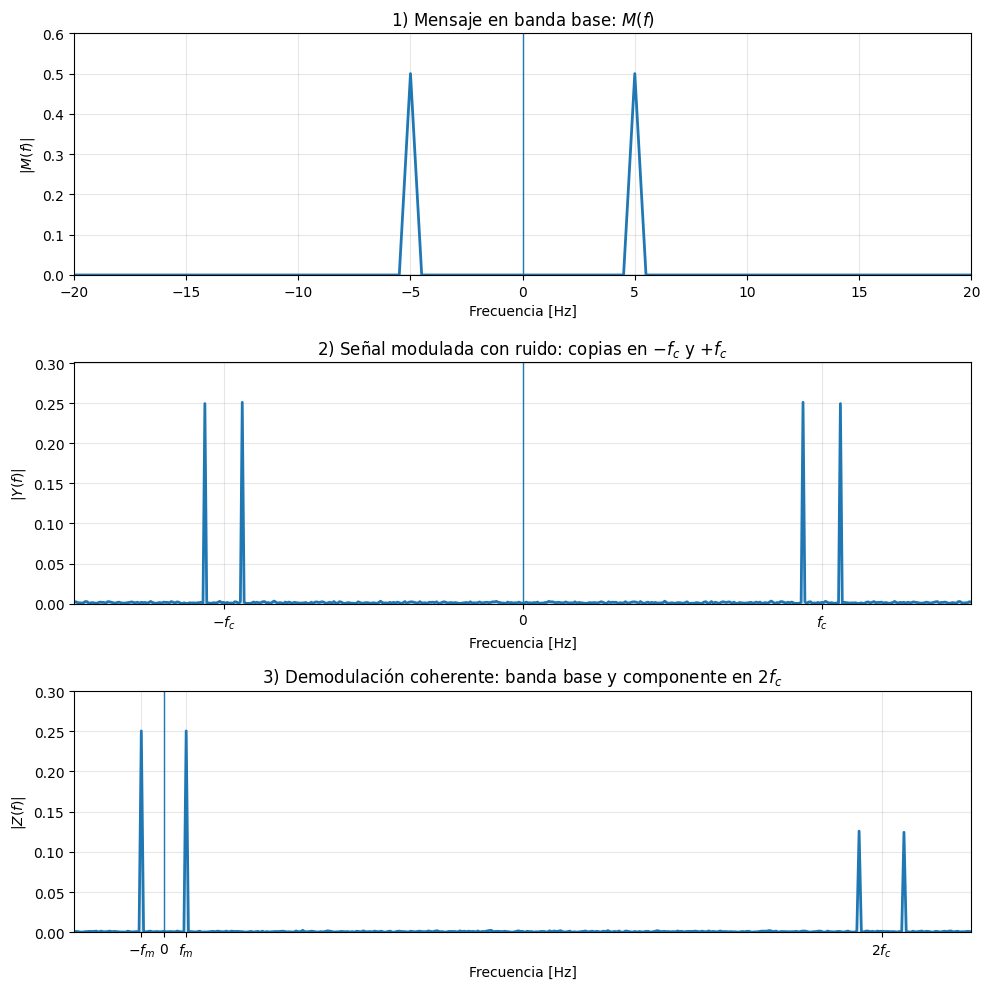

In [ ]:
import torch
import matplotlib.pyplot as plt

# ============================================================
# 1. PARÁMETROS GENERALES
# ============================================================

fs = 5000          # frecuencia de muestreo [Hz]
T = 2              # duración de la simulación [s]
N = int(fs * T)    # número total de muestras

t = torch.arange(N) / fs

fm = 5             # frecuencia del mensaje [Hz]
fc = 80            # frecuencia portadora [Hz]

# ============================================================
# 2. MENSAJE EN BANDA BASE
#    m(t)
# ============================================================

m = torch.cos(2 * torch.pi * fm * t)

# ============================================================
# 3. MODULACIÓN DSB-SC
#    s(t) = m(t) cos(2 pi fc t)
# ============================================================

carrier = torch.cos(2 * torch.pi * fc * t)

s = m * carrier

# ============================================================
# 4. CANAL CON RUIDO AWGN EN BANDA PASANTE
#    y(t) = m(t) cos(w0 t) + n_I(t) cos(w0 t) - n_Q(t) sin(w0 t)
# ============================================================

sigma_n = 0.5
n_I = sigma_n * torch.randn(N)
n_Q = sigma_n * torch.randn(N)

y = m * carrier + n_I * carrier - n_Q * torch.sin(2 * torch.pi * fc * t)

# ============================================================
# 5. DEMODULACIÓN COHERENTE
#    z(t) = y(t) cos(2 pi fc t)
# ============================================================

z = y * carrier

# ============================================================
# 6. FILTRO PASA BAJAS Y RECUPERACIÓN
# ============================================================

Y_demod = torch.fft.fft(z)
freqs = torch.fft.fftfreq(N, d=1 / fs)

cutoff = 15
mask = torch.abs(freqs) <= cutoff

Z_filtered = Y_demod * mask

m_rec = 2 * torch.real(torch.fft.ifft(Z_filtered))

# ============================================================
# 7. ESPECTROS
# ============================================================

freq = torch.fft.fftshift(torch.fft.fftfreq(N, d=1 / fs))

M = torch.fft.fftshift(torch.fft.fft(m))
S = torch.fft.fftshift(torch.fft.fft(s))
Y = torch.fft.fftshift(torch.fft.fft(y))
Z = torch.fft.fftshift(torch.fft.fft(z))

M_mag = torch.abs(M) / N
S_mag = torch.abs(S) / N
Y_mag = torch.abs(Y) / N
Z_mag = torch.abs(Z) / N

# ============================================================
# 8. MÉTRICAS DE RUIDO Y SNR
# ============================================================

error = m - m_rec
P_signal = torch.mean(m ** 2)
P_noise = torch.mean(error ** 2)
SNR = P_signal / P_noise
SNR_dB = 10 * torch.log10(SNR)
mean_error = torch.mean(torch.abs(error))

print(f"Potencia de la señal: {P_signal.item():.4f}")
print(f"Potencia del error: {P_noise.item():.4f}")
print(f"SNR: {SNR.item():.4f}")
print(f"SNR (dB): {SNR_dB.item():.2f} dB")
print(f"Error medio absoluto: {mean_error.item():.4f}")

# ============================================================
# 9. GRÁFICAS
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(10, 12), constrained_layout=True)

axes[0].plot(t[:800], m[:800], label="m(t)")
axes[0].plot(t[:800], m_rec[:800], linestyle="--", label="m_rec(t)")
axes[0].set_title("Señal mensaje original y señal recuperada")
axes[0].set_ylabel("Amplitud")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t[:800], s[:800], label="s(t) transmitida")
axes[1].plot(t[:800], y[:800], alpha=0.7, label="y(t) recibida")
axes[1].set_title("Señal AM transmitida y señal recibida con ruido")
axes[1].set_ylabel("Amplitud")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(freq, S_mag, label="S(f)")
axes[2].plot(freq, Y_mag, alpha=0.8, label="Y(f)")
axes[2].set_xlim(-120, 120)
axes[2].set_title("Espectro de la señal AM transmitida y recibida")
axes[2].set_ylabel("Magnitud")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(freq, M_mag, label="M(f)")
axes[3].plot(freq, Z_mag, alpha=0.8, label="Z(f)")
axes[3].set_xlim(-20, 20)
axes[3].set_title("Espectro de banda base original y demodulado")
axes[3].set_ylabel("Magnitud")
axes[3].set_xlabel("Frecuencia [Hz]")
axes[3].legend()
axes[3].grid(True)

plt.show()



# Conclusiones finales

- La señal mensaje se describe en banda base y su espectro original se traslada a las bandas laterales alrededor de \(\pm f_c\) tras la modulación AM. Esto muestra la estructura típica de una señal DSB-SC.
- El modelo de ruido AWGN en fase \(n_I(t)\) y en cuadratura \(n_Q(t)\) muestra que solo el ruido en fase permanece después de la demodulación coherente. El ruido en cuadratura se limita a altas frecuencias y se elimina con un filtro pasa bajas.
- El análisis espectral antes y después de añadir ruido confirma que el ruido añade energía alrededor de la portadora y que la demodulación produce una copia en banda base junto a componentes en \(\pm 2f_c\).
- La demodulación coherente y el filtrado recuperan la señal mensaje, pero la calidad de la señal recuperada queda limitada por la potencia del ruido y por la sincronización de fase del receptor.
- La relación señal a ruido (SNR) cuantifica cómo el ruido degrada la señal recuperada: una SNR menor se traduce en mayor error y menor fidelidad del mensaje.
- En conclusión, una señal AM puede transmitirse y recuperarse en presencia de ruido, pero la calidad final depende de la potencia del ruido, la sincronización del receptor y la eficacia del filtrado de banda base.

